In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [108]:
# Load dataset
df = pd.read_csv(r"C:\\Users\\ACER\\Downloads\\IMDb Movies India.csv\\IMDb Movies India.csv", encoding='latin1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [109]:
# Display basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB
None


In [110]:
# Combine actor columns into a single 'Actors' column
df['Actors'] = df[['Actor 1', 'Actor 2', 'Actor 3']].apply(lambda x: ', '.join(x.dropna()), axis=1)

In [ ]:
df.head()

In [111]:
# Selecting relevant columns (Assuming 'Rating' is the target variable)
selected_feature = ["Genre", "Director", "Actors", "Rating"]
df = df[selected_feature].dropna()

In [127]:
df.head()

,Genre,Director,Actors,Rating
1,Drama,Gaurav Bakshi,"Rasika Dugal, Vivek Ghamande, Arvind Jangid",7.0
3,"Comedy, Romance",Ovais Khan,"Prateik, Ishita Raj, Siddhant Kapoor",4.4
5,"Comedy, Drama, Musical",Rahul Rawail,"Bobby Deol, Aishwarya Rai Bachchan, Shammi Kapoor",4.7
6,"Drama, Romance, War",Shoojit Sircar,"Jimmy Sheirgill, Minissha Lamba, Yashpal Sharma",7.4
8,"Horror, Mystery, Thriller",Allyson Patel,"Yash Dave, Muntazir Ahmad, Kiran Bhatia",5.6


In [113]:
# One-Hot Encoding for Director
encoder = OneHotEncoder(handle_unknown="ignore")
director_encoded = encoder.fit_transform(df[["Director"]]).toarray()
director_labels = encoder.get_feature_names_out(["Director"])
director_df = pd.DataFrame(director_encoded, columns = director_labels)

In [114]:
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
genre_tfidf = tfidf.fit_transform(df['Genre']).toarray()
genre_df = pd.DataFrame(genre_tfidf, columns=tfidf.get_feature_names_out())

actors_tfidf = tfidf.fit_transform(df['Actors']).toarray()
actors_df = pd.DataFrame(actors_tfidf, columns=tfidf.get_feature_names_out())


In [115]:
director_df.head()

,Director_A. Bhimsingh,Director_A. Jagannathan,Director_A. Kodandarami Reddy,Director_A. Majid,Director_A. Muthu,Director_A. Salaam,Director_A. Shamsheer,Director_A. Veerappan,Director_A. Venkatesh,Director_A.C. Trilogchander,...,Director_Zaigham Ali Syed,Director_Zaigham Imam,Director_Zakir Khan,Director_Zanane Rajsingh,Director_Zeishan Quadri,Director_Zia Sarhadi,Director_Ziaullah Khan,Director_Zoya Akhtar,Director_Zubair Khan,Director_Zunaid Memon
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [116]:
genre_df.head()

,action,adventure,animation,biography,comedy,crime,documentary,drama,family,fantasy,...,music,musical,mystery,news,romance,sci,sport,thriller,war,western
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.721153,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.692776,0.0,0.0,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.539511,0.0,0.0,0.305748,0.0,0.0,...,0.0,0.784504,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.208112,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.352776,0.0,0.0,0.000000,0.912271,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.601655,0.0,0.000000,0.0,0.0,0.473937,0.000000,0.0


In [117]:
actors_df.head()

,aamir,abhay,abhi,abhishek,abraham,adil,aditi,aditya,aftab,agarwal,...,vivek,vyjayanthimala,waheeda,walker,warsi,yadav,yash,yogeeta,zeenat,zinta
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.658506,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.481346,0.0,0.0,0.0


In [118]:
# Combine all features into a single dataframe for training
X = pd.concat([director_df, genre_df, actors_df], axis=1)
y = df['Rating']

In [119]:
X.head()

,Director_A. Bhimsingh,Director_A. Jagannathan,Director_A. Kodandarami Reddy,Director_A. Majid,Director_A. Muthu,Director_A. Salaam,Director_A. Shamsheer,Director_A. Veerappan,Director_A. Venkatesh,Director_A.C. Trilogchander,...,vivek,vyjayanthimala,waheeda,walker,warsi,yadav,yash,yogeeta,zeenat,zinta
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.658506,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.481346,0.0,0.0,0.0


In [120]:
y.head()

1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64

In [121]:
# Splitting data into train and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

In [123]:
# Train models
# 1. Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

In [125]:
# 2. Random Forest Regressor Model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

In [129]:
# Evaluate models using R-squared and RMSE metrics
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{model_name} Model Evaluation")
    print(f"R-squared: {r2_score(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)


Linear Regression Model Evaluation
R-squared: -133817174754580846138621952.0000
RMSE: 16037885640958.4297

Random Forest Model Evaluation
R-squared: 0.2161
RMSE: 1.2275


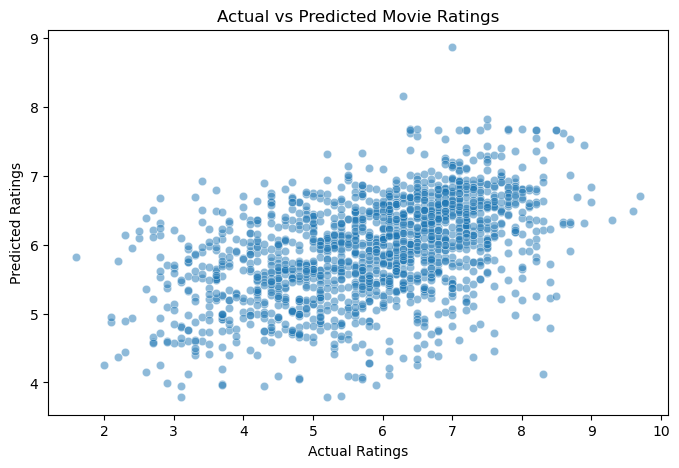

In [131]:
# Plot actual vs predicted ratings
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()